In [155]:
from pathlib import Path
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

from skimage.feature import learn_gmm, fisher_vector

DATASET_ROOT = Path("TinyImageNet100_2026")
if not (DATASET_ROOT / "class_name.txt").exists() and (DATASET_ROOT / "TinyImageNet100_2026" / "class_name.txt").exists():
    DATASET_ROOT = DATASET_ROOT / "TinyImageNet100_2026"
assert DATASET_ROOT.exists(), f"Dataset root not found: {DATASET_ROOT}"
print("Dataset root:", DATASET_ROOT)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

N_CLASSES = 15
N_TRAINING_PER_CLASS = 400
N_TESTING_PER_CLASS  = 100

UPSCALE_TO = 96  
BOW_K_LISTS = [256, 512]  
GMM_K_LISTS = [16, 32]     
SVM_C_LISTS = [1.0, 2.0]   

MAX_DESCR_PER_IMG = 120
CODEBOOK_MAX_IMGS = 500
GMM_MAX_IMGS = 250

CACHE = {"kmeans": {}, "gmm": {}, "dev_feats": {}}

print("OpenCV:", cv2.__version__, "| Has SIFT:", hasattr(cv2, "SIFT_create"))
assert hasattr(cv2, "SIFT_create"), "Install opencv-contrib-python and restart kernel."

Dataset root: TinyImageNet100_2026
OpenCV: 4.13.0 | Has SIFT: True


To avoid long runtime, we:
small sweep over K and C
- Fit k-means & GMM with fewer images and fewer descriptors per image.
- Store the fitted objects & features in memory only.
MiniBatchKMeans is designed for scalability since it uses mini-batches.

In [156]:
def lists_classes_ids(root: Path) -> list[str]:
    return sorted([p1.name for p1 in root.iterdir() if p1.is_dir()])

def choose_random_classes(class_ids: list[str], n: int, seed: int) -> list[str]:
    rng = random.Random(seed)
    return sorted(rng.sample(class_ids, n))

def get_sorted_images(root: Path, class_id: str) -> list[Path]:
    return sorted((root / class_id / "images").glob("*.JPEG")) 

def build_split_classes(root: Path, selected: list[str]):
    Xtr1, ytr1, Xte1, yte1 = [], [], [], []
    for cids in selected:
        images = get_sorted_images(root, cids)
        if len(images) < (N_TRAINING_PER_CLASS + N_TESTING_PER_CLASS):
            raise ValueError(f"{cids} has {len(images)} images; expected >= {N_TRAINING_PER_CLASS + N_TESTING_PER_CLASS}")
        tr1 = images[:N_TRAINING_PER_CLASS]
        te1 = images[N_TRAINING_PER_CLASS:N_TRAINING_PER_CLASS + N_TESTING_PER_CLASS]
        Xtr1.extend(tr1); ytr1.extend([cids]*len(tr1))
        Xte1.extend(te1); yte1.extend([cids]*len(te1))
    return Xtr1, ytr1, Xte1, yte1

def read_class(root: Path) -> dict[str, str]:
    fn = root / "class_name.txt"
    mp = {}
    if not fn.exists():
        return mp
    with fn.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) >= 2 and parts[0].startswith("n"):
                mp[parts[0]] = parts[1]
                continue
            parts = line.split(maxsplit=1)
            if len(parts) == 2 and parts[0].startswith("n"):
                mp[parts[0]] = parts[1]
    return mp

all_classes = lists_classes_ids(DATASET_ROOT)
selected_classes = choose_random_classes(all_classes, N_CLASSES, SEED)

X_train_paths, y_train_ids, X_test_paths, y_test_ids = build_split_classes(DATASET_ROOT, selected_classes)

print("Selected classes:", selected_classes)
print("Train size:", len(X_train_paths), "Expected:", N_CLASSES * N_TRAINING_PER_CLASS)
print("Test size :", len(X_test_paths),  "Expected:", N_CLASSES * N_TESTING_PER_CLASS)

probes = selected_classes[0]
probes_imgs = get_sorted_images(DATASET_ROOT, probe)
print("\nSplit proof for:", probes)
print("Train first/last:", [p1.name for p1 in probes_imgs[:3]], "...", [p1.name for p1 in probes_imgs[397:400]])
print("Test  first/last:", [p1.name for p1 in probes_imgs[400:403]], "...", [p1.name for p1 in probes_imgs[497:500]])

ler = LabelEncoder()
ler.fit(selected_classes)
y_train = ler.transform(y_train_ids)
y_test  = ler.transform(y_test_ids)

name_map = read_class(DATASET_ROOT)
label_display = [name_map.get(cids, cids) for cids in ler.classes_]

Selected classes: ['n03393912', 'n03400231', 'n03599486', 'n03637318', 'n03649909', 'n03706229', 'n03902125', 'n03970156', 'n03983396', 'n04311004', 'n04532106', 'n04597913', 'n07695742', 'n07747607', 'n09193705']
Train size: 6000 Expected: 6000
Test size : 1500 Expected: 1500

Split proof for: n03393912
Train first/last: ['n03393912_0.JPEG', 'n03393912_1.JPEG', 'n03393912_10.JPEG'] ... ['n03393912_456.JPEG', 'n03393912_457.JPEG', 'n03393912_458.JPEG']
Test  first/last: ['n03393912_459.JPEG', 'n03393912_46.JPEG', 'n03393912_460.JPEG'] ... ['n03393912_97.JPEG', 'n03393912_98.JPEG', 'n03393912_99.JPEG']


Phase 1 (What happens here?)
- Randomly select 15 classes with a fixed seed.
- For every selected class, we will sort the filenames and split:
– first 400 to train
- remaining 100 to test
- We print a split proof to show we adhere to the rule.

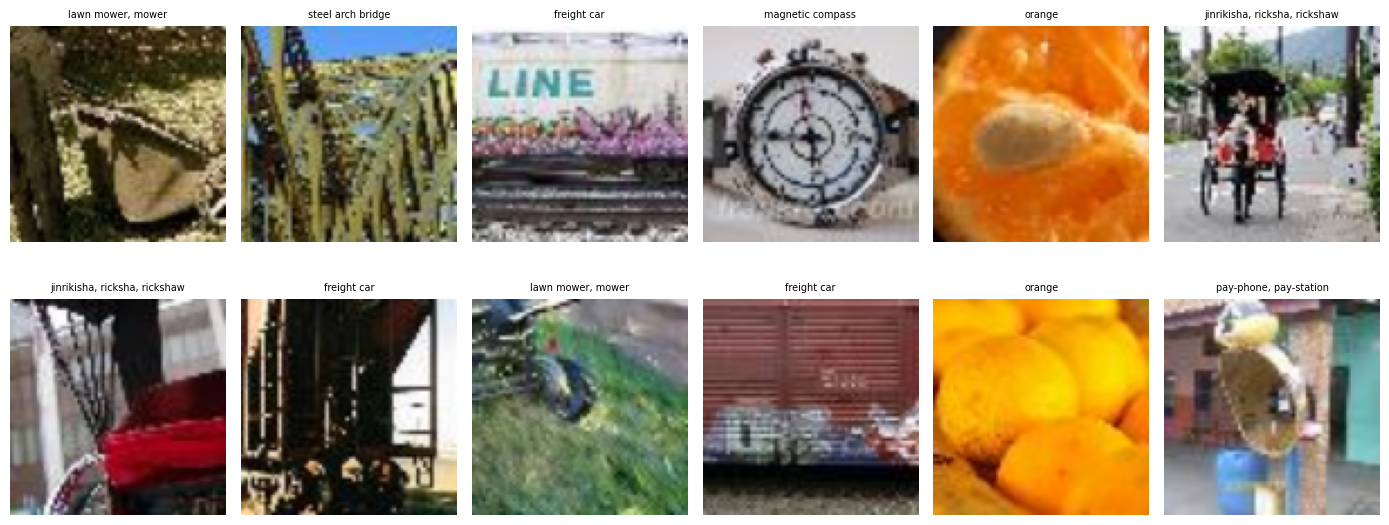

In [157]:
def load_bgr(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(path)
    if UPSCALE_TO is not None and (image.shape[0] != UPSCALE_TO or image.shape[1] != UPSCALE_TO):
        image = cv2.resize(image, (UPSCALE_TO, UPSCALE_TO), interpolation=cv2.INTER_LINEAR)
    return image

def show_image_grid(paths, titles, n1=12, cols=6, figsize=(14, 6)):
    n1 = min(n1, len(paths))
    rows1 = int(np.ceil(n1/ cols))
    plt.figure(figsize=figsize)
    for i in range(n1):
        image = cv2.cvtColor(load_bgr(paths[i]), cv2.COLOR_BGR2RGB)
        plt.subplot(rows1, cols, i+1)
        plt.imshow(image)
        plt.axis("off")
        plt.title(titles[i], fontsize=7)
    plt.tight_layout()
    plt.show()

idx = np.random.choice(len(X_train_paths), size=12, replace=False)
paths = [X_train_paths[i] for i in idx]
titles = [name_map.get(y_train_ids[i], y_train_ids[i]) for i in idx]
show_image_grid(paths, titles, n1=12)

Phase 1 qualitative check
We visualize a few training images to confirm:
- loads the data set correctly
- labels are mapped correctly
- preprocessing works

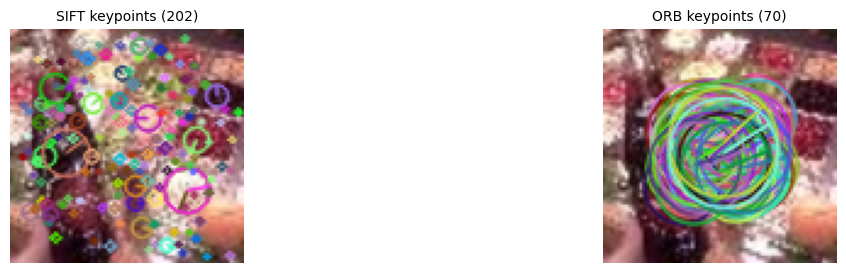

In [158]:
def load_gray(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(path)
    if UPSCALE_TO is not None and (image.shape[0] != UPSCALE_TO or image.shape[1] != UPSCALE_TO):
        image = cv2.resize(image, (UPSCALE_TO, UPSCALE_TO), interpolation=cv2.INTER_LINEAR)
    return image

class LocalExtractor:
    def __init__(self, method: str, nfeatures: int = 800):
        self.method = method.lower().strip()
        if self.method == "sift":
            self.det = cv2.SIFT_create(nfeatures=nfeatures)
            self.dim = 128
        elif self.method == "orb":
            self.det = cv2.ORB_create(nfeatures=nfeatures)
            self.dim = 32
        else:
            raise ValueError("method must be 'sift' or 'orb'")

    def detect_and_describe(self, gray: np.ndarray):
        kps, des = self.det.detectAndCompute(gray, None)
        if des is None:
            des = np.empty((0, self.dim), dtype=np.float32)
        return kps, des.astype(np.float32, copy=False)

sift = LocalExtractor("sift", nfeatures=800)
orb  = LocalExtractor("orb",  nfeatures=1200)

sample_paths = [X_train_paths[i] for i in np.random.choice(len(X_train_paths), size=3, replace=False)]
plt.figure(figsize=(12, 8))
for r1, p in enumerate(sample_paths):
    gray = load_gray(p)
    bgr  = load_bgr(p)

    kp_s, _ = sift.detect_and_describe(gray)
    kp_o, _ = orb.detect_and_describe(gray)

    vis_s = cv2.drawKeypoints(bgr, kp_s, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    vis_o = cv2.drawKeypoints(bgr, kp_o, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    plt.subplot(3, 2, 2*r+1); plt.imshow(cv2.cvtColor(vis_s, cv2.COLOR_BGR2RGB)); plt.axis("off")
    plt.title(f"SIFT keypoints ({len(kp_s)})", fontsize=10)

    plt.subplot(3, 2, 2*r+2); plt.imshow(cv2.cvtColor(vis_o, cv2.COLOR_BGR2RGB)); plt.axis("off")
    plt.title(f"ORB keypoints ({len(kp_o)})", fontsize=10)

plt.tight_layout()
plt.show()

Why SIFT and ORB?
Both the methods are local feature methods, which mean they are utilized for detecting keypoints and computing descriptors.
- SIFT keypoints + descriptors: It is a robust tool that is commonly used for keypoint/descriptor extraction.
- ORB corresponds to a combination of FAST features + BRIEF descriptors with modifications.
We get a varying number of descriptors with each image, hence the need to use BoW or Fisher Vector to produce a fixed-length vector.

In [159]:
def sample_descriptors(paths, extractor: LocalExtractor, maxx_images: int, max_des_per_img: int):
    rng = np.random.default_rng(SEED)
    picked = paths[:maxx_images]
    all_des = []
    for p in picked:
        gray = load_gray(p)
        _, des = extractor.detect_and_describe(gray)
        if des.shape[0] == 0:
            continue
        if des.shape[0] > MAX_DESCR_PER_IMG:
            idx = rng.choice(des.shape[0], size=max_des_per_img, replace=False)
            des = des[idx]
        all_des.append(des)
    if not all_des:
        raise RuntimeError(f"No descriptors found for {extractor.method}. Try UPSCALE_TO=96 or raise nfeatures.")
    return np.vstack(all_des)

Why we sample descriptors:
Fitting k-means/GMM on all the descriptors from all the images is computationally and memory intensive.
It is also common practice to sample a subset of the images and limit the descriptors per image.

In [160]:
def fit_bow_codebook(train_paths, extractor: LocalExtractor, bow_k: int):
    des = sample_descriptors(train_paths, extractor, maxx_images=CODEBOOK_MAX_IMGS, max_des_per_img=MAX_DESCR_PER_IMG)
    kmeans = MiniBatchKMeans(n_clusters=bow_k, random_state=SEED, batch_size=4096, n_init="auto")
    kmeans.fit(des)
    return kmeans

def bow_encode_image(des: np.ndarray, kmeans: MiniBatchKMeans, bow_k: int) -> np.ndarray:
    hist = np.zeros((bow_k,), dtype=np.float32)
    if des.shape[0] == 0:
        return hist
    words = kmeans.predict(des)
    np.add.at(hist, words, 1.0)

    s1 = hist.sum()
    if s1 > 0:
        hist /= s1
    hist = np.sqrt(hist)
    n2 = np.linalg.norm(hist)
    if n2 > 0:
        hist /= n2
    return hist

def bow_features(paths, extractor: LocalExtractor, kmeans: MiniBatchKMeans, bow_k: int) -> np.ndarray:
    X1 = np.zeros((len(paths), bow_k), dtype=np.float32)
    for i, p in enumerate(paths):
        gray = load_gray(p)
        _, des = extractor.detect_and_describe(gray)
        X1[i] = bow_encode_image(des, kmeans, bow_k)
    return X1

BoW : Bag of Visual Words
- Fit k-means (visual vocabulary) using MiniBatchKMeans for speed.
Label each image as a histogram of visual word assignments.

In [161]:
def fit_gmm(train_paths, extractor: LocalExtractor, gmm_k: int):
    desc_list = []
    rng = np.random.default_rng(SEED)

    for p in train_paths[:GMM_MAX_IMGS]:
        gray = load_gray(p)
        _, des = extractor.detect_and_describe(gray)
        if des.shape[0] == 0:
            continue
        if des.shape[0] > MAX_DESCR_PER_IMG:
            idx = rng.choice(des.shape[0], size=MAX_DESCR_PER_IMG, replace=False)
            des = des[idx]
        desc_list.append(des)

    if not desc_list:
        raise RuntimeError(f"No descriptors for GMM ({extractor.method}).")

    gmm = learn_gmm(desc_list,n_modes=gmm_k,
        gm_args={"covariance_type": "diag", "random_state": SEED, "max_iter": 150, "reg_covar": 1e-6})
    return gmm

def fisher_features(paths, extractor: LocalExtractor, gmm, gmm_k: int) -> np.ndarray:
    fv_dim = 2 * gmm_k * extractor.dim + gmm_k
    X1 = np.zeros((len(paths), fv_dim), dtype=np.float32)
    for i, p in enumerate(paths):
        gray = load_gray(p)
        _, des = extractor.detect_and_describe(gray)
        if des.shape[0] == 0:
            continue
        fv = fisher_vector(des, gmm, improved=True, alpha=0.5)
        X1[i] = fv.astype(np.float32, copy=False)
    return X1

Fisher Vector+FV+GMM
FV is an concatenation of gradients of a GMM w.r.t. weights/means/covariances.
- FV in scikit-image has been very rigidly forcing `covariance_type='diag' for the GMM.
- improved=True applies power + L2 normalization, with power parameter alpha.
FV can be interpreted as a probabilistic alternative to BoW.

In [162]:
def train_eval_linear_svm(Xtr1, ytr1, Xte1, yte1, C: float, title: str, Display_details: bool = True):
    clf = LinearSVC(C=C, max_iter=6000, dual="auto", random_state=SEED)
    clf.fit(Xtr1, ytr1)
    preds = clf.predict(Xte1)
    acc = accuracy_score(yte1, preds)

    if Display_details:
        print(f"\n[{title}] C={C} | Accuracy={acc:.4f}\n")
        print(classification_report(yte1, preds, target_names=label_display))
        ConfusionMatrixDisplay.from_predictions(yte1, preds, display_labels=label_display, xticks_rotation=90)
        plt.title(f"Confusion Matrix - {title} (C={C})")
        plt.tight_layout()
        plt.show()

    return clf, preds, acc

Why Linear SVM?
SVMs are useful for high-dimensional feature spaces like BoW+FV.
Linear SVC has been created to be scalable compared to kernel SVC based on the number of samples and features.
ConfusionMatrixDisplay provides an in-notebook confusion matrix plot.

In [163]:
def make_dev_subset_per_class(X_paths, y_ids, per_class: int, seed: int):
    rng = np.random.default_rng(seed)
    X_dev, y_dev = [], []
    for cid in sorted(set(y_ids)):
        idx = [i for i, y in enumerate(y_ids) if y == cid]
        take = min(per_class, len(idx))
        pick = rng.choice(idx, size=take, replace=False)
        X_dev.extend([X_paths[i] for i in pick])
        y_dev.extend([y_ids[i] for i in pick])
    return X_dev, y_dev

DEV_TRAINING_PER_CLASS = 80
DEV_TESTING_PER_CLASS  = 30

Xtr_dev, ytr_dev_ids = make_dev_subset_per_class(X_train_paths, y_train_ids, DEV_TRAINING_PER_CLASS, SEED)
Xte_dev, yte_dev_ids = make_dev_subset_per_class(X_test_paths,  y_test_ids,  DEV_TESTING_PER_CLASS,  SEED)

ytr_dev = ler.transform(ytr_dev_ids)
yte_dev = ler.transform(yte_dev_ids)

print("DEV train:", len(Xtr_dev), " DEV test:", len(Xte_dev))

DEV train: 1200  DEV test: 450


Dev subset tuning
Sweeping on the full 7,500 images can be very slow.
We tune on a smaller per-class dev subset, then train once on the full split with the best hyperparameters.

In [164]:
def get_bow_feats_dev(extractor: LocalExtractor, bow_k: int):
    keys = (extractor.method, "BoW", bow_k)
    if keys in CACHE["dev_feats"]:
        return CACHE["dev_feats"][keys]

    km_key = (extractor.method, bow_k)
    if km_key not in CACHE["kmeans"]:
        CACHE["kmeans"][km_key] = fit_bow_codebook(Xtr_dev, extractor, bow_k)

    kmeans = CACHE["kmeans"][km_key]
    Xtr1 = bow_features(Xtr_dev, extractor, kmeans, bow_k)
    Xte1 = bow_features(Xte_dev, extractor, kmeans, bow_k)
    CACHE["dev_feats"][keys] = (Xtr1, Xte1)
    return Xtr1, Xte1

def get_fv_feats_dev(extractor: LocalExtractor, gmm_k: int):
    keys = (extractor.method, "FV", gmm_k)
    if keys in CACHE["dev_feats"]:
        return CACHE["dev_feats"][keys]

    gmm_key = (extractor.method, gmm_k)
    if gmm_key not in CACHE["gmm"]:
        CACHE["gmm"][gmm_key] = fit_gmm(Xtr_dev, extractor, gmm_k)

    gmm = CACHE["gmm"][gmm_key]
    Xtr1 = fisher_features(Xtr_dev, extractor, gmm, gmm_k)
    Xte1 = fisher_features(Xte_dev, extractor, gmm, gmm_k)
    CACHE["dev_feats"][keys] = (Xtr1, Xte1)
    return Xtr1, Xte1

results = []

for extractor in [sift, orb]:
    for bow_k in BOW_K_LIST:
        Xtr1, Xte1 = get_bow_feats_dev(extractor, bow_k)
        for C in SVM_C_LIST:
            _, _, acc = train_eval_linear_svm(Xtr1, ytr_dev, Xte1, yte_dev, C=C,title=f"{extractor.method.upper()}+BoW(K={bow_k}) DEV",
                                              Display_details=False)
            results.append({"feature": extractor.method.upper(), "encoding": "BoW", "K": bow_k, "C": C, "dev_acc": acc})

    for gmm_k in GMM_K_LISTS:
        Xtr1, Xte1 = get_fv_feats_dev(extractor, gmm_k)
        for C in SVM_C_LIST:
            _, _, acc = train_eval_linear_svm(Xtr1, ytr_dev, Xte1, yte_dev, C=C,title=f"{extractor.method.upper()}+FV(GMM_K={gmm_k}) DEV",
                                              Display_details=False)
            results.append({"feature": extractor.method.upper(), "encoding": "FV", "K": gmm_k, "C": C, "dev_acc": acc})

df_dev = pd.DataFrame(results).sort_values("dev_acc", ascending=False).reset_index(drop=True)
df_dev.head(15)

,feature,encoding,K,C,dev_acc
0,SIFT,FV,16,1.0,0.273333
1,SIFT,FV,32,1.0,0.268889
2,SIFT,FV,16,2.0,0.248889
3,SIFT,FV,32,2.0,0.246667
4,SIFT,BoW,256,1.0,0.244444
5,SIFT,BoW,256,2.0,0.208889
6,SIFT,BoW,512,1.0,0.202222
7,SIFT,BoW,512,2.0,0.193333
8,ORB,BoW,256,1.0,0.122222
9,ORB,BoW,256,2.0,0.117778


Dev subset tuning
It is quite slow running sweeping on the entire 7,500 images.
We tune on a smaller per-class dev subset, and then we train once on the full split with the best hyperparameters.
We sweep
- BoW K ∈ {256, 512}
- FV GMM_K ∈ {16, 32
- SVM C ∈ {1, 2}

In [165]:
best = df_dev.iloc[0]
print("Best DEV config:", best.to_dict())
summary = (df_dev.groupby(["feature", "encoding"]).first().reset_index().sort_values("dev_acc", ascending=False))

Best DEV config: {'feature': 'SIFT', 'encoding': 'FV', 'K': 16, 'C': 1.0, 'dev_acc': 0.2733333333333333}


BoW vs Fisher Vector comparison
This summary shows the best dev accuracy for:
- SIFT+BoW, ORB+BoW
- SIFT+FV,  ORB+FV


Training BEST config on FULL split...
Best: SIFT FV K= 16 C= 1.0

[SIFT+FV(GMM_K=16) FULL] C=1.0 | Accuracy=0.3387

                               precision    recall  f1-score   support

                  freight car       0.42      0.44      0.43       100
  frying pan, frypan, skillet       0.31      0.30      0.30       100
jinrikisha, ricksha, rickshaw       0.45      0.52      0.48       100
        lampshade, lamp shade       0.32      0.34      0.33       100
            lawn mower, mower       0.23      0.22      0.22       100
             magnetic compass       0.53      0.56      0.55       100
       pay-phone, pay-station       0.45      0.48      0.46       100
    plunger, plumber's helper       0.30      0.27      0.29       100
      pop bottle, soda bottle       0.22      0.17      0.19       100
            steel arch bridge       0.41      0.43      0.42       100
                     vestment       0.19      0.13      0.15       100
                 wooden spoon 

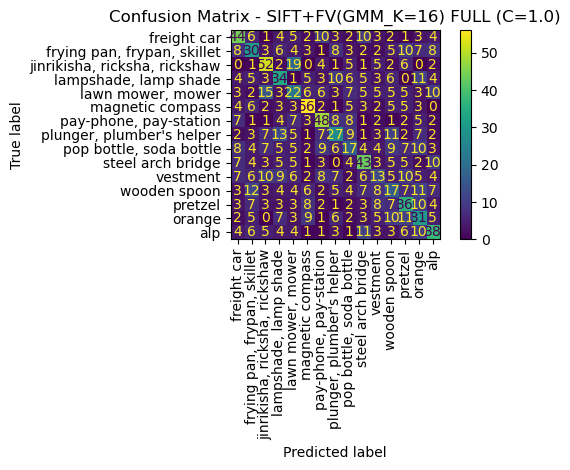

FULL test accuracy: 0.33866666666666667


In [166]:
best_feat = best["feature"]
best_enc  = best["encoding"]
best_K    = int(best["K"])
best_C    = float(best["C"])

extractor = sift if best_feat == "SIFT" else orb

print("\nTraining BEST config on FULL split...")
print("Best:", best_feat, best_enc, "K=", best_K, "C=", best_C)

if best_enc == "BoW":
    kmeans_full = fit_bow_codebook(X_train_paths, extractor, best_K)
    Xtr_full = bow_features(X_train_paths, extractor, kmeans_full, best_K)
    Xte_full = bow_features(X_test_paths,  extractor, kmeans_full, best_K)

    svm_full, pred_full, acc_full = train_eval_linear_svm(Xtr_full, y_train, Xte_full, y_test, C=best_C,
        title=f"{best_feat}+BoW(K={best_K}) FULL", Display_details=True)
    final_model = {"feature": best_feat, "encoding": "BoW", "K": best_K, "C": best_C,"kmeans": kmeans_full, "svm": svm_full, "test_acc": acc_full}

else:
    gmm_full = fit_gmm(X_train_paths, extractor, best_K)
    Xtr_full = fisher_features(X_train_paths, extractor, gmm_full, best_K)
    Xte_full = fisher_features(X_test_paths,  extractor, gmm_full, best_K)

    svm_full, pred_full, acc_full = train_eval_linear_svm(Xtr_full, y_train, Xte_full, y_test, C=best_C,
        title=f"{best_feat}+FV(GMM_K={best_K}) FULL", Display_details=True)
    final_model = {"feature": best_feat, "encoding": "FV", "K": best_K, "C": best_C,
                   "gmm": gmm_full, "svm": svm_full, "test_acc": acc_full}

print("FULL test accuracy:", acc_full)

Evidence of good performance
These factors have the
After tuning on the development set, we retune the best configuration on the entire training set as well as the entire test set.
We print:
- accuracy
- classification report
- confusion matrix

Correct: 508 Wrong: 992


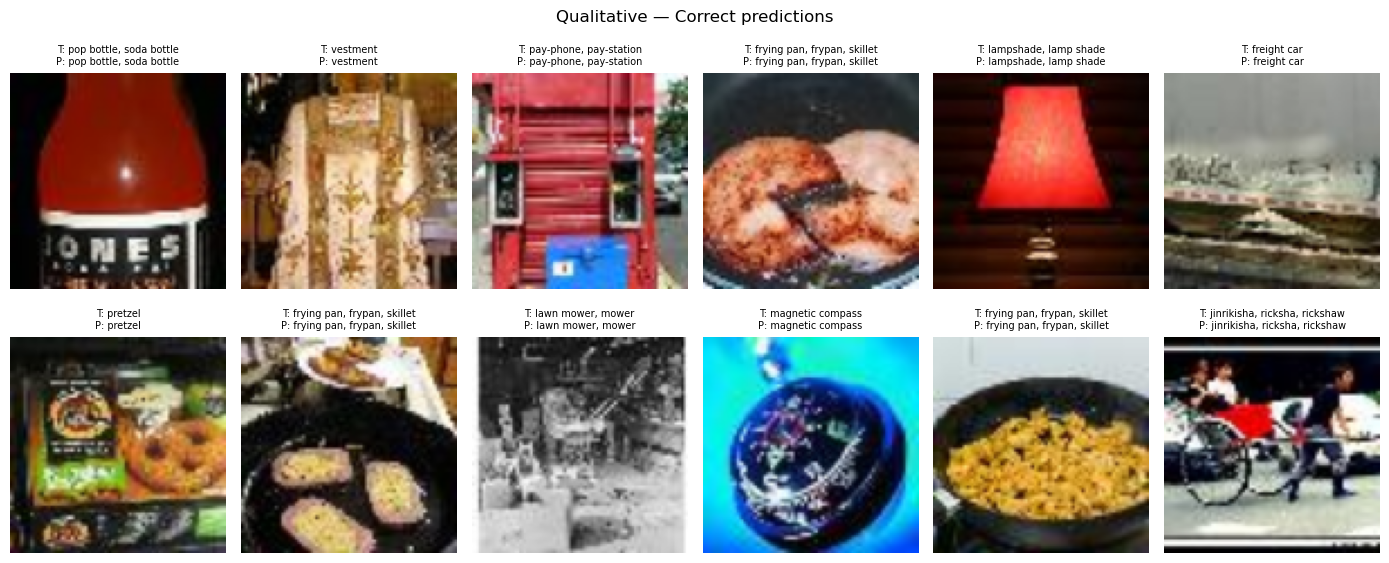

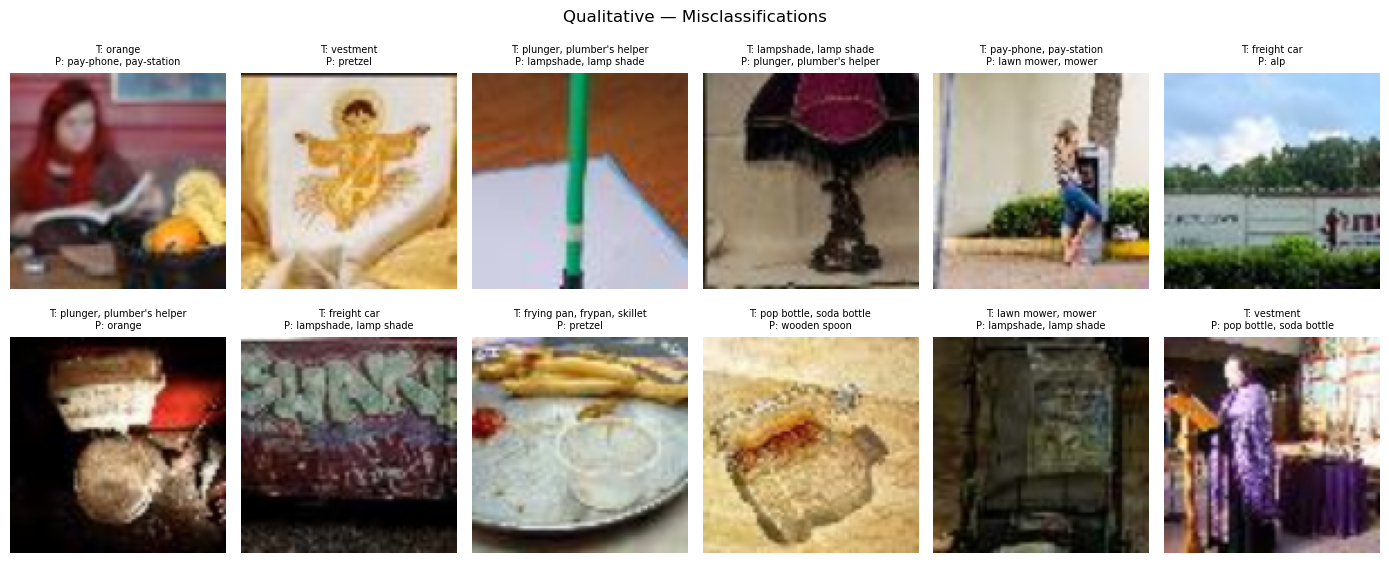

In [168]:
def show_predictions(paths, true_ids, pred_int, n=12, cols=6, title=""):
    n = min(n, len(paths))
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(14, 6))
    for i in range(n):
        img = cv2.cvtColor(load_bgr(paths[i]), cv2.COLOR_BGR2RGB)
        true_id = true_ids[i]
        pred_id = le.inverse_transform([pred_int[i]])[0]
        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"T: {name_map.get(true_id,true_id)}\nP: {name_map.get(pred_id,pred_id)}", fontsize=7)
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

correct_idx = np.where(pred_full == y_test)[0]
wrong_idx   = np.where(pred_full != y_test)[0]

print("Correct:", len(correct_idx), "Wrong:", len(wrong_idx))

if len(correct_idx) > 0:
    pick = np.random.choice(correct_idx, size=min(12, len(correct_idx)), replace=False)
    show_predictions([X_test_paths[i] for i in pick],
                     [y_test_ids[i] for i in pick],
                     pred_full[pick],
                     title="Qualitative — Correct predictions")

if len(wrong_idx) > 0:
    pick = np.random.choice(wrong_idx, size=min(12, len(wrong_idx)), replace=False)
    show_predictions([X_test_paths[i] for i in pick],
                     [y_test_ids[i] for i in pick],
                     pred_full[pick],
                     title="Qualitative — Misclassifications")

Qualitative evaluation
We show:
- a grid of correct predictions
- a grid of misclassifications
The foregoing visuals provide an explanation towards failure modes.

Discussion
1) SIFT vs ORB Comparison of Accuracy and Confusion Troutbeck suggests that while ORB is quicker to perform than SIFT, it may not possess the same level
2) BoW vs FV:BoW is based on counting visual words, whereas FV is based on the idea of deviations from a
3) Hyperparameter effects: Explain the effect of K (BoW/GMM_K) and C using the sweep table on the model’s accuracy 4) Error Analysis: Use confusion matrix & misclassified images to explain the classes that are confused & why.

In [169]:
import joblib
from pathlib import Path
import glob

needed_ones = ["selected_classes", "le", "label_display", "df_dev", "best", "final_model"]
missings = [v1 for v1 in needed if v1 not in globals()]
assert not missing, f"Run the missing parts first. Missing: {missings}"

bundle = { "seed": SEED,"selected_classes": selected_classes,"label_encoder": le,"label_names": label_display,"dev_sweep_table": df_dev,
    "best_dev_config": best.to_dict(),"final_model": final_model}

out = Path.cwd() / "cw1_best_model.joblib"
saved_files = joblib.dump(bundle, out, compress=3)

print("Saved files:", saved_files)
print("Exists?", out.exists(), "| Size (MB):", round(out.stat().st_size / (1024**2), 2))
print("Found:", glob.glob("cw1_best_model*"))

Saved files: ['C:\\Users\\sarih\\cw1_best_model.joblib']
Exists? True | Size (MB): 0.51
Found: ['cw1_best_model.joblib']


Save the trained model bundle (cw1_best_model.joblib)
This cell saves everything necessary to reproduce my results into one file named 'cw1_best_model.joblib'.
Checks for presence of required variables ('selected_classes', 'df_dev', 'final_model',
Missing any might indicate that I have skipped some cells or perhaps even restarted the kernel.
- Creates a 'bundle' dictionary with:
- the random seed + selected 15 classes (for reproducibility),
- the label encoder + label names (class mapping),
- the dev sweep table + best config (tuning evidence),
- the final trained model (SVM + BoW/FV encoder).
- Writes the bundle to disk using 'joblib.dump(.)' (standard persisting a sklearn object).
- Uses compression ('compress = 3') for the reduction of file size.
- Prints proof of saving:
'Saved files:' displays the files that were written by ‘joblib.dump’; ‘joblib.dump’ returns a list containing the names of the files
- 'Exists?' and file size verify the creation of the model file.
- 'Found: displays any saved files found within the folder.

I use chatgpt for minimal support inorder to clarify doubts and to troubleshoot.However, all code execution result,conclusion are my own.